Intercept: -0.16263576950187475
Coefficients: {'N': 0.004674252254400745, 'ProjectedFieldCount': 0.0034513272305863674}
R^2 Score: 0.9839668868209949
Plots saved.


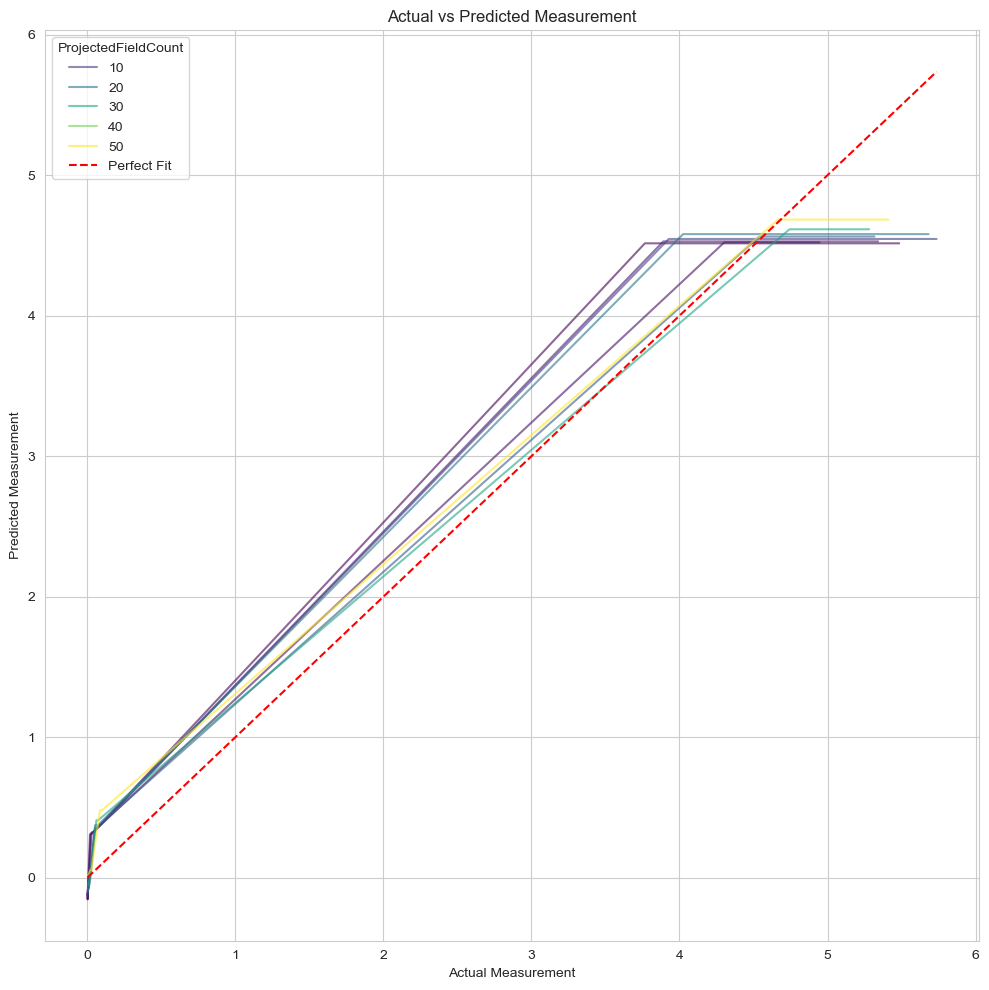

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Reload and filter
df = pd.read_csv('data/projection/projection_performance_data.csv')

# Parse Params
def parse_params(param_str):
    parts = param_str.split('&')
    params_dict = {}
    for part in parts:
        key, val = part.split('=')
        params_dict[key] = int(val)
    return params_dict

df_params = df['Params'].apply(parse_params).apply(pd.Series)
df = pd.concat([df, df_params], axis=1)

# Filter for Result stage
df_result = df[df['Measurement_IterationStage'] == 'Result'].copy()

df_result['Measurement_Value'] = df_result['Measurement_Value'] / 1_000_000

# Features and Target
X = df_result[['N', 'ProjectedFieldCount']]
y = df_result['Measurement_Value']

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predictions
df_result['Predicted_Value'] = model.predict(X)

# Print model info
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {dict(zip(X.columns, model.coef_))}")
print(f"R^2 Score: {r2_score(y, df_result['Predicted_Value'])}")

# Visualization 1: Actual vs Predicted
plt.figure(figsize=(10, 10))
sns.lineplot(data=df_result, x='Measurement_Value', y='Predicted_Value', hue='ProjectedFieldCount', palette='viridis', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', label='Perfect Fit')
plt.title('Actual vs Predicted Measurement')
plt.xlabel('Actual Measurement')
plt.ylabel('Predicted Measurement')
plt.legend(title='ProjectedFieldCount')
plt.tight_layout()
plt.savefig('images/projection/actual_vs_predicted.png')

print("Plots saved.")